In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import datasets
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, IterableDataset, get_worker_info
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
from torchcodec.decoders import VideoDecoder
import os
import random

/home/rianbutala/projects/wm2/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def patchify(tensor, seq_len):
  # takes tensor of b,c,h,w
  # returns b,s,c tensor
  B, C, H, W = tensor.shape
  assert H==W # square patch
  assert int(seq_len**0.5) ** 2 == seq_len
  assert (H*W)%seq_len ==0

  scaling_factor = int(H/(seq_len**0.5))
  tensor = tensor.reshape(B,C,H//scaling_factor, scaling_factor, W//scaling_factor,scaling_factor)
  tensor = tensor.permute(0,2,4,1,3,5)
  tensor = tensor.reshape(B, H//scaling_factor* W//scaling_factor, C*scaling_factor*scaling_factor)
  return tensor

def unpatchify(tensor,height):
  # assume h,w is the same
  width=height
  B, S, C = tensor.shape
  scaling_factor = int(height/(S**0.5))
  # tensor shape as it stands: b, h//scf * w//scf, c*scf*scf
  image_c = C//scaling_factor//scaling_factor
  tensor = tensor.reshape(B,height//scaling_factor,width//scaling_factor,image_c,scaling_factor,scaling_factor)
  tensor = tensor.permute(0,3,1,4,2,5)
  # b,c,h//scf,scf,w//scf,scf
  tensor = tensor.reshape(B,image_c,height,width)
  return tensor

def tubeify(tensor, seq_len, frames_per_tube=2):
  # takes tensor of b,c,h,w
  # returns b,s,c tensor
  B, T, C, H, W = tensor.shape
  t_shortened = T//frames_per_tube
  assert H==W # square patch
  assert int(seq_len**0.5) ** 2 == seq_len
  assert (H*W)%seq_len ==0

  scaling_factor = int(H/(seq_len**0.5))
  tensor = tensor.reshape(B,t_shortened, frames_per_tube, C,H//scaling_factor, scaling_factor, W//scaling_factor,scaling_factor)
  # tensor = tensor.permute(0,2,4,1,3,5)
  tensor = tensor.permute(0,1,4,6,3,2,5,7)
  tensor = tensor.reshape(B, t_shortened, H//scaling_factor* W//scaling_factor, C*frames_per_tube*scaling_factor*scaling_factor)
  return tensor

def untubeify(tensor,height, frames_per_tube=2):
  # assume h,w is the same
  width=height
  B, t_shortened, S, C = tensor.shape
  scaling_factor = int(height/(S**0.5))
  # tensor shape as it stands: b, h//scf * w//scf, c*scf*scf
  image_c = C//scaling_factor//scaling_factor//frames_per_tube
  tensor = tensor.reshape(B,t_shortened,height//scaling_factor,width//scaling_factor,image_c,frames_per_tube,scaling_factor,scaling_factor)
  # tensor = tensor.permute(0,3,1,4,2,5)
  # b,c,h//scf,scf,w//scf,scf
  tensor = tensor.permute(0,1,5,4,2,6,3,7)
  tensor = tensor.reshape(B,t_shortened*frames_per_tube, image_c,height,width)
  return tensor

example = torch.rand(1,3,256,256)
print(f"patch: {patchify(example, seq_len=256).shape}")
print(f"unpatch: {unpatchify(patchify(example,seq_len=256),height=256).shape}")
tube_example = torch.rand(1,48,3,256,256)
print(f"tube: {tubeify(tube_example, seq_len=256, frames_per_tube=2).shape}")
print(f"untube: {untubeify(tubeify(tube_example,seq_len=256,frames_per_tube=2), height=256,frames_per_tube=2).shape}")


patch: torch.Size([1, 256, 768])
unpatch: torch.Size([1, 3, 256, 256])
tube: torch.Size([1, 24, 256, 1536])
untube: torch.Size([1, 48, 3, 256, 256])


In [3]:
class VideoDataset(Dataset):
  def __init__(self, root, transform=None, seq_len=256, frames=30, frames_per_tube=2):
    self.data_root = root
    self.frames=frames
    self.transform = transform
    self.seq_len = seq_len
    self.frames_per_tube=frames_per_tube
  def __len__(self):
    file_count = sum(1 for entry in os.scandir(self.data_root) if entry.is_file())
    return file_count

  def __getitem__(self, idx):
    frame_tensors = VideoDecoder(
        os.path.join(self.data_root, f'{idx+1}.webm')
    )[:].to(torch.float32) / 255.0
    frame_tensors = self.transform(frame_tensors)
    frame_height = frame_tensors.size(2)
    frame_tensors = patchify(frame_tensors, self.seq_len)  # (t, s, c)
    # frame_tensors = tubeify(frame_tensors.unsqueeze(0), seq_len=self.seq_len, frames_per_tube=self.frames_per_tube).squeeze(0)

    t, s, c = frame_tensors.shape
    assert s == self.seq_len, f"patch dim {s} != seq_len {self.seq_len}"

    # (t, s, c) -> (t*s, c)
    frame_tensors = frame_tensors.reshape(t * s, c)

    total = t * s
    target_len = self.frames * self.seq_len

    if total < target_len:
        pad_len = target_len - total
        frame_tensors = F.pad(frame_tensors, (0, 0, pad_len, 0))  # front-pad seq dim
    else:
        start = random.randint(0, int(total - target_len))
        frame_tensors = frame_tensors[start:start + target_len]

    # (target_len, c) -> (frames, seq_len, c)
    frame_tensors = frame_tensors.reshape(self.frames, self.seq_len, c)
    frame_tensors = unpatchify(frame_tensors, frame_height)
    # print(f"sanity: {frame_tensors.shape}")
    frame_tensors = tubeify(frame_tensors.unsqueeze(0), seq_len=self.seq_len, frames_per_tube=self.frames_per_tube).squeeze(0)
    return frame_tensors

In [4]:
transform = transforms.Compose([
    transforms.Resize((256,256)),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])
seq_len = 256
model_dim = 1536
frames_per_tube=2
target_frames = 30//frames_per_tube # target tubes now...
target_seq = target_frames*seq_len
ds = VideoDataset("./data/20bn-something-something-v2", transform, seq_len=seq_len, frames=target_frames*frames_per_tube, frames_per_tube=frames_per_tube)
print(next(iter(ds)).shape)
dl = DataLoader(ds, batch_size=2, num_workers=4)
print(next(iter(dl)).shape)

torch.Size([15, 256, 1536])


torch.Size([2, 15, 256, 1536])


In [5]:
class Block(nn.Module):
  def __init__(self,nhead=4,seq=target_seq,emb=768):
    super().__init__()
    # print(f"block received init emb {emb}")
    self.seq=seq
    self.emb=emb
    self.nhead=nhead
    assert emb%nhead==0

    self.ln1 = nn.LayerNorm(emb)
    self.qkv_proj = nn.Linear(emb,emb*3)
    self.o_proj = nn.Linear(emb,emb)

    self.ln2 = nn.LayerNorm(emb)
    self.mlp = nn.Sequential(
      nn.Linear(emb,emb*4),
      nn.GELU(),
      nn.Linear(emb*4,emb)
    )
    
  def forward(self,x):
    # x shape b,s,c
    b,s,c=x.shape
    # x = self.ln1(x)
    qkv=self.qkv_proj(self.ln1(x))
    q,k,v = qkv.chunk(3,dim=-1)
    q = q.view(b,s,self.nhead,c//self.nhead).transpose(2,1)
    k = k.view(b,s,self.nhead,c//self.nhead).transpose(2,1)
    v = v.view(b,s,self.nhead,c//self.nhead).transpose(2,1)

    attn_out = F.scaled_dot_product_attention(q,k,v)
    attn_out = attn_out.transpose(2,1).contiguous().reshape(b,s,c)
    attn_out = self.o_proj(attn_out)
    # x += attn_out
    x = x+attn_out

    # x += self.mlp(self.ln2(x))
    x = x+self.mlp(self.ln2(x))

    return x

class Encoder(nn.Module):
  # todo add positional embeddings and maybe patch embeddings idk
  # todo add layer norm
  def __init__(self,nlayer=4,nhead=4,seq=target_seq,emb=768):
    super().__init__()
    self.blocks=nn.ModuleList([Block(nhead,seq,emb) for _ in range(nlayer)])
    self.ln_out = nn.LayerNorm(emb)

  def forward(self,x):
    b,t,s,c = x.shape
    x = x.reshape(b,t*s,c)
    # pos_emb = embed(context_indices)
    # x+=pos_emb
    for block in self.blocks:
      x = block(x)

    # return self.ln_out(x)
    x = self.ln_out(x)
    return x.reshape(b,t,s,c)

class Predictor(nn.Module):
  def __init__(self,nlayer=4,nhead=4,seq=target_seq,emb=768,dim=384):
    super().__init__()
    self.blocks=nn.ModuleList([Block(nhead,seq,dim) for _ in range(nlayer)]) #normally head,seq,emb but we downcast
    # self.register_buffer("emb_idx", torch.arange(0,seq))
    self.down=nn.Linear(emb,dim)
    self.up=nn.Linear(dim,emb)
    self.ln_out = nn.LayerNorm(emb)
    
  def forward(self,x):
    b,t,s,c = x.shape
    x = x.reshape(b,t*s,c)
    # print("predictor forward")
    x = self.down(x)
    # print("down")
    # pos_emb = embed(self.emb_idx)
    # x+=pos_emb
    # print("start loop")
    for block in self.blocks:
      # print("loop")
      x = block(x)

    # print("loop done")
    x = self.up(x)
    # print("up")
    x= self.ln_out(x)
    return x.reshape(b,t,s,c)

# quick warning for anyone reading this with their own human eyes: yes i know all the variables have the wrong names no i will not change it
class InformedPredictor(nn.Module):
  def __init__(self,seq=seq_len,emb=768,masked_tokens=10,frames=target_frames, frames_per_tube=frames_per_tube):
    super().__init__()
    # important sketchy code announcement
    emb = emb*frames_per_tube
    
    self.encoder = Encoder(seq=seq,emb=emb)
    self.target_encoder = Encoder(seq=seq,emb=emb)
    self.predictor = Predictor(seq=seq,emb=emb)
    assert masked_tokens <= seq
    self.seq=seq
    self.emb=emb
    self.masked_tokens=masked_tokens
    self.embed_mlp = nn.Sequential(
      nn.LayerNorm(emb),
      nn.Linear(emb,emb),
    )
    self.frames = frames
    self.embed = nn.Embedding(seq,emb)
    self.frame_embed =nn.Embedding(frames,emb)
    nn.init.trunc_normal_(self.embed.weight, std=.02)
    self.register_buffer("pos_idx", torch.arange(0,seq))
    self.register_buffer("frame_idx", torch.arange(0,frames))
    # self.register_buffer("mask_token_embedding", torch.ones(self.masked_tokens,emb))
    self.mask_token_embedding = nn.Parameter(torch.randn(1,emb))

    self.target_encoder.load_state_dict(self.encoder.state_dict())
    for p in self.target_encoder.parameters():
      p.requires_grad = False

  def forward(self,x):
    # x = patchify(x,self.seq)
    b,t,s,c = x.shape
    # x += self.embed(self.pos_idx)
    x = self.embed_mlp(x)
    x = x+self.embed(self.pos_idx)
    x = x+self.frame_embed(self.frame_idx).unsqueeze(1)
    # print(f"sanity: {self.frame_embed(self.frame_idx).shape}")
    x_orig = x.clone()
    # b,256,768 for ex.

    # inv_masked_token_idx = torch.randint(0,self.seq,torch.Size([self.seq-self.masked_tokens]))
    # inv_masked_token_idx = torch.randperm(self.seq-self.masked_tokens)
    all_perms = torch.randperm(self.seq, device=x.device)
    inv_masked_token_idx = all_perms[:self.seq-self.masked_tokens]
    filtered_x =x [:,:,inv_masked_token_idx,:]

    encoded_x = self.encoder(filtered_x) #b,seq-mask,c
    mask = torch.isin(self.pos_idx,inv_masked_token_idx) # which elements of inv masked token idx in pos idx
    mask_token_idx = self.pos_idx[~mask]
    mask_tokens = self.embed(mask_token_idx).unsqueeze(0).expand(b,-1,-1,-1)
    mask_tokens = mask_tokens+self.mask_token_embedding.unsqueeze(0).expand(b,t,self.masked_tokens,-1)

    # print(f"sanity: {encoded_x.shape, mask_tokens.shape}")
    predicted_x = self.predictor(torch.cat([encoded_x,mask_tokens],dim=-2)) # b,s,c
    with torch.no_grad():
      encoded_x = self.target_encoder(x_orig)

    mask_pred = predicted_x[:,:,self.seq-self.masked_tokens:,:]
    target_pred = encoded_x[:,:,mask_token_idx,:]
    return mask_pred, target_pred


In [6]:
example = next(iter(dl))
print(example.shape)
with torch.no_grad():
  jepa=InformedPredictor()
  out, filtered_out = jepa(example)
  print(out.shape,filtered_out.shape)

  enc=Encoder(emb=768*frames_per_tube)
  print(enc(example).shape)
  # print(enc(patchify(example,256)).shape)
  # enc(filtered_out).shape

torch.Size([2, 15, 256, 1536])
torch.Size([2, 15, 10, 1536]) torch.Size([2, 15, 10, 1536])
torch.Size([2, 15, 256, 1536])


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# torch.autograd.set_detect_anomaly(True, check_nan=False)
model = InformedPredictor(masked_tokens=int(0.8*seq_len), frames = target_frames).to(device)
compiled_model = torch.compile(model)
loss_fn = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=1e-4)
losses = []

steps = 15000
loss_every = 100
ema_beta = 0.999
dl_iter = iter(dl)
pbar = tqdm(total=steps)
# for step in tqdm(range(steps)):
for step in range(steps):
  try:
    data = next(dl_iter).to(device)
    # data = torch.randn((1,3,256,256))
  except StopIteration:
    dl_iter = iter(dl)
    data = next(dl_iter).to(device)

  with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    mask_pred, target_pred = compiled_model(data)
    loss = loss_fn(mask_pred, target_pred)
  # print(f"loss: {loss.item()}")
  loss.backward()
  optimizer.step()
  optimizer.zero_grad()
  pbar.update(1)
  pbar.set_postfix(loss=loss.item())

  if step%loss_every==0:
    losses.append(loss.item())

  for param, reference in zip(model.target_encoder.parameters(), model.encoder.parameters()):
    param.data.mul_(ema_beta).add_(reference.data, alpha=1-ema_beta)

100%|██████████| 15000/15000 [28:47<00:00,  9.71it/s, loss=0.206] 

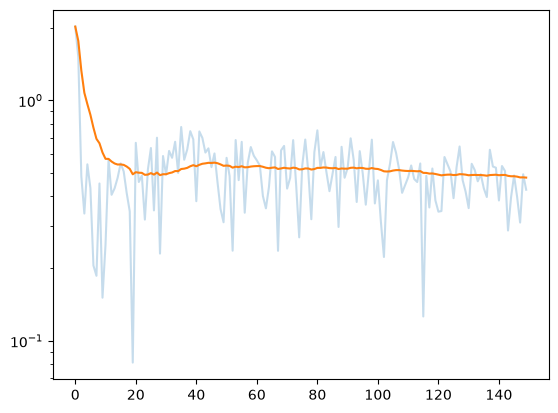

In [8]:
import numpy as np
losses_arr = np.array(losses)
ema = np.zeros_like(losses_arr)
beta,acc=0.98,0.0
for i,l in enumerate(losses_arr):
  acc = beta*acc+(1-beta)*l
  ema[i] = acc/(1-beta**(i+1))
plt.plot(losses_arr,alpha=0.25,label="raw")
plt.plot(ema,label="ema")
plt.yscale("log")
plt.show()